In [1]:
# IMPORTACIÓN DE LIBRERIAS
import os 
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score

c:\Users\davbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\davbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\davbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

In [2]:
# RUTA A IMAGENES
# data_dir = Path(r"C:\Temas Auditoria\Usados\Prueba Runt\Modelo\Imagenes Modelo V2 Limpias")
data_dir = Path(r"C:\Users\davbo\Documents\Maestria en Ciencias de los Datos y Analitica\Proyecto Integrador II\Modelo\Imagenes Modelo V2 Limpias")

# LISTA DE IMAGENES
# images = sorted(list(map(str, list(data_dir.glob("**.png") ))))
images = sorted(map(str, data_dir.glob("**/*.png")))

# LISTA DE LABELS (NOMBRES DE IMAGENES)
labels = [img.split(os.path.sep)[-1].split(".png")[0] for img in images]

# LISTA DE CARACTERES
characters = set(char for label in labels for char in label) 
characters = sorted(list(characters))

print("Number of images found: ", len(images)) 
print("Number of labels found: ", len(labels)) 
print("Number of unique characters: ", len(characters)) 
print("Characters present: ", characters)


# TAMAÑO DE LOTE DE ENTRENAMIENTO
batch_size = 16
# batch_size = 8


# DIMENSIONES DE LA IMAGEN 
img_width =  210
img_height = 60

'''
Factor por el cual se reducirá la resolución de la imagen # por los bloques convolucionales. 
estaremos usando dos # bloques de convolución y cada bloque tendrá # una capa de agrupación que 
reduce la muestra de las características por un factor de 2. # Por lo tanto, el factor de reducción 
de muestreo total sería 4. 
'''

downsample_factor = 4

# LONGITUD MAXIMA PARA CUALQUIER CAPTCHA DEL DATASET
max_length = max([len(label) for label in labels])

Number of images found:  3457
Number of labels found:  3457
Number of unique characters:  56
Characters present:  ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [3]:
max_length

6

In [4]:
# Mapear caracteres a números enteros
char_to_num = layers.StringLookup(
    vocabulary=list(characters), mask_token=None
)

# Mapear enteros a los caracteres originales
num_to_char = layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)

In [5]:
def encode_single_sample(img_path, label):

    # 1. Leer imagen 
    img = tf.io.read_file(img_path)

    # 2. Comvertir a escala de grises 
    img = tf.io.decode_png(img, channels=1) #[Altura , Ancho , Canales ] channels = 1 es ecala de grises 

    # 3. Convertir a float32 in [0, 1] range
    img = tf.image.convert_image_dtype(img, tf.float32)

    # 4. Mantener la forma de la imagen siempre.
    img = tf.image.resize(img, [img_height, img_width]) #[Altura= 53 , Ancho=204 , Canales=1 ]

    # 5. Transpose the image because we want the time
    # dimension to correspond to the width of the image.
    img = tf.transpose(img, perm=[1, 0, 2]) #[Altura= 204 , Ancho=53 , Canales=1 ]

    # 6. Mapear los caracteres de la etiquetas a numeros
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
    
    # 7. Retornar un diccionario con dos input de esta forma entrara al modelo
    return {"image": img, "label": label}

In [6]:
def split_data(images, labels, train_size=0.9, shuffle=True):
    # 1. Tomamos el tamaño total de los datos 
    size = len(images)
    # 2. Tomamos los indices con el valor de tamaño de los datos.
    indices = np.arange(size)
    if shuffle:
        np.random.shuffle(indices)

    # 3. Tomamos el tamaño de los datos de entrenamiento 
    train_samples = int(size * train_size)

    # 4. Separamos lod datos entre los datos de entrenamiento y validacion 
    x_train, y_train = images[indices[:train_samples]], labels[indices[:train_samples]]
    x_valid, y_valid = images[indices[train_samples:]], labels[indices[train_samples:]]
    return x_train, x_valid, y_train, y_valid


# Aplicamos la funcion para tomar nuestros datos de validacion y entrenamiento 
x_train, x_valid, y_train, y_valid = split_data(np.array(images), np.array(labels))

In [288]:
# # DATOS DE ENTRENAMIENTO 
# # Convertimos los datos de entrenamiento a un objeto de tipo tf.data.dataset
# # Mapeamos cada uno de nuestros datos pasandola por la funcion encode_simple_sample ademar de tomar los lotes de tamaño batch_size = 16

# train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
# train_dataset = (
#     train_dataset.map(
#         encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE
#     )
#     .batch(batch_size)
#     .prefetch(buffer_size=tf.data.AUTOTUNE)
# )

# # DATOS DE VALIDACION 

# validation_dataset = tf.data.Dataset.from_tensor_slices((x_valid, y_valid))
# validation_dataset = (
#     validation_dataset.map(
#         encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE
#     )
#     .batch(batch_size)
#     .prefetch(buffer_size=tf.data.AUTOTUNE)
# )

In [7]:
# DATOS DE ENTRENAMIENTO 
# Convertimos los datos de entrenamiento a un objeto de tipo tf.data.dataset
# Mapeamos cada uno de nuestros datos pasandola por la funcion encode_simple_sample ademar de tomar los lotes de tamaño batch_size = 16

train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        batch_size,
        padded_shapes={"image": [img_width,img_height, 1], "label": [max_length]},
        padding_values={"image": 0.0, "label": tf.constant(0, dtype=tf.int64)}
    )
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

validation_dataset = (
    tf.data.Dataset.from_tensor_slices((x_valid, y_valid))
    .map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        batch_size,
        padded_shapes={"image": [img_width,img_height, 1], "label": [max_length]},
        padding_values={"image": 0.0, "label": tf.constant(0, dtype=tf.int64)}
    )
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)


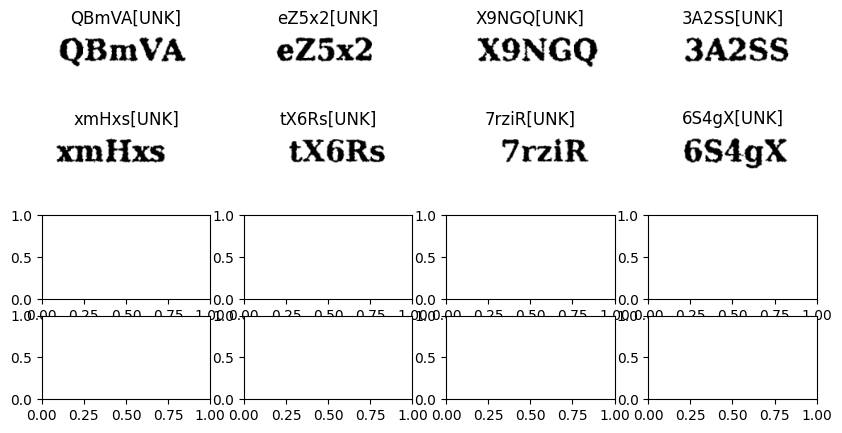

In [8]:
# VISUALIZAMOS UN LOTE DE LOS DATOS DE ENTRENAMIENTO.

_, ax = plt.subplots(4, 4, figsize=(10, 5))
for batch in train_dataset.take(1):
    images = batch["image"]
    labels = batch["label"]
    for i in range(8):
        img = (images[i] * 255).numpy().astype("uint8")
        label = tf.strings.reduce_join(num_to_char(labels[i])).numpy().decode("utf-8")
        ax[i // 4, i % 4].imshow(img[:, :, 0].T, cmap="gray")
        ax[i // 4, i % 4].set_title(label)
        ax[i // 4, i % 4].axis("off")
plt.show()

In [9]:
# class CTCLayer(layers.Layer):
#     def __init__(self, name=None):
#         super().__init__(name=name)
#         self.loss_fn = keras.backend.ctc_batch_cost

#     def call(self, y_true, y_pred):
#         # Compute the training-time loss value and add it
#         # to the layer using `self.add_loss()`.
#         batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
#         input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
#         label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

#         input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
#         label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

#         loss = self.loss_fn(y_true, y_pred, input_length, label_length)
#         self.add_loss(loss)

#         # At test time, just return the computed predictions
#         return y_pred

class CTCLayer(keras.layers.Layer):
    def __init__(
        self,
        trainable=True,   # Keras le pasa esto
        name=None,        # y esto
        dtype=None,       # y esto
        **kwargs          # cualquier otro argumento que Keras agregue
    ):
        super().__init__(trainable=trainable, name=name, dtype=dtype, **kwargs)
        self.loss_fn = keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
        label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

        input_length = input_length * tf.ones((batch_len, 1), dtype="int64")
        # CAMBIADOOO
        # label_length = label_length * tf.ones((batch_len, 1), dtype="int64")
        label_length = tf.reduce_sum(tf.cast(y_true != 0, tf.int64), axis=1, keepdims=True)


        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

    def get_config(self):
        # esto devuelve name, trainable, dtype, etc.
        return super().get_config()

    @classmethod
    def from_config(cls, config):
        # Keras usa esto para reconstruir la capa
        return cls(**config)


In [292]:
# def build_model():
#     # ENTRADA DE IMAGEN AL MODELO 
#     input_img = layers.Input(
#         shape=(img_width, img_height, 1), name="image", dtype="float32"
#     )

#     # ENTRADA DE ETIQUETA AL MODELO

#     labels = layers.Input(name="label", shape=(None,), dtype="int64")

#     # PRIMER BLOQUE CONVOLUCIONAL 

#     x = layers.Conv2D(
#         32,
#         (3, 3),
#         activation = "relu",                  
#         kernel_initializer="he_normal",
#         padding="same",
#         name="Conv1",
#     )(input_img)

#     # REDUCE LA IMAGEN 
#     # Tomando los valores maximos de cada uno de los valores en el mapa de caracteristicas 
#     # (2,2) es el tamaño de la matriz que pasara por cada uno.

#     x = layers.MaxPooling2D((2, 2), name="pool1")(x)

#     # SEGUNDO BLOQUE CONVOLUCIONAL
#     # 64 , la dimensionalidad del espacio de salida (es decir, el número de filtros de salida en la convolución) tambien podriamos llamarlo los canales .
#     # (3,3) tamaño de la matriz de convolucion que pasra por la imagen.
#     # kernel_initializer="he_normal" , inicia con pesos aleatorios numeros positivos o negativos que seran partes de la matriz de convolucion.

#     x = layers.Conv2D(
#         64,                          
#         (3, 3),
#         activation="relu", 
#         kernel_initializer="he_normal",
#         padding="same",
#         name="Conv2",
#     )(x)

#     # REDUCE LA IMAGEN 
#     # Tomando los valores maximos de cada uno de los valores en el mapa de caracteristicas 
#     # (2,2) es el tamaño de la matriz que pasara por cada uno.

#     x = layers.MaxPooling2D((2, 2), name="pool2")(x)

#     # Hemos usado dos max pool con tamaño de pool y strides 2.
#     # Por lo tanto, los mapas de características remuestreados son 4 veces más pequeños. El número de
#     # filtros en la última capa es 64. Remodelar en consecuencia antes de
#     # pasar la salida a la parte RNN del modelo

#     # FLATTEN 
#     # Reducir una red de 2 dimenciones(matriz) a una sola dimencion(vector) de tamaño 64.

#     new_shape = ((img_width // 4), (img_height // 4) * 64)
#     x = layers.Reshape(target_shape=new_shape, name="reshape")(x)
    
#     x = layers.Dense(64, activation="relu", name="dense1")(x)
#     x = layers.Dropout(0.2)(x)


#     # RNNs
#     # Entrenamiento bidireccional,la pediccion resultante de la prediccion en el tiempo t , sera tomado encuenta 
#     # pueden depender de la entrada en el tiempo t+1 , usado habitualmente para aplicaciones de traduccion automatica.
#     # Dimencionalidad de la read aumenta aun vector lineal de tamaño (128)
#     # Dimencionalidad de la read disminuye a un vector lineal de tamaño (64)

#     x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
#     x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(x)

#     # SALIDA DE LA RED 
#     # Se reduce la red a solo 5 salida que es la longitud de nuetro capcha 
#     x = layers.Dense(
#         len(char_to_num.get_vocabulary()) + 1, activation="softmax", name="dense2"
#     )(x)


#     # Agregar  CTC layer para calcular la perdida CTC loss por cada paso.
#     output = CTCLayer(name="ctc_loss")(labels, x) # labels = entrenamiento y x = prediccion final 

#     # Define the model
#     model = keras.models.Model(
#         inputs=[input_img, labels], outputs=output, name="ocr_model_v1"
#     )
#     # Optimizer
#     opt = keras.optimizers.Adam()
#     # Compile the model and return
#     model.compile(optimizer=opt)
#     return model


# # Get the model
# model = build_model()
# model.summary()

In [10]:
def build_model():
    # ENTRADA DE IMAGEN AL MODELO 
    input_img = layers.Input(
        shape=(img_width, img_height, 1), name="image", dtype="float32"
    )

    # ENTRADA DE ETIQUETA AL MODELO

    labels = layers.Input(name="label", shape=(None,), dtype="int64")

    # PRIMER BLOQUE CONVOLUCIONAL 

    x = layers.Conv2D(
        32,
        (3, 3),
        activation = "relu",                  
        kernel_initializer="he_normal",
        padding="same",
        name="Conv1",
    )(input_img)

    # REDUCE LA IMAGEN 
    # Tomando los valores maximos de cada uno de los valores en el mapa de caracteristicas 
    # (2,2) es el tamaño de la matriz que pasara por cada uno.

    x = layers.MaxPooling2D((2, 2), name="pool1")(x)

    # SEGUNDO BLOQUE CONVOLUCIONAL
    # 64 , la dimensionalidad del espacio de salida (es decir, el número de filtros de salida en la convolución) tambien podriamos llamarlo los canales .
    # (3,3) tamaño de la matriz de convolucion que pasra por la imagen.
    # kernel_initializer="he_normal" , inicia con pesos aleatorios numeros positivos o negativos que seran partes de la matriz de convolucion.

    x = layers.Conv2D(
        64,                          
        (3, 3),
        activation="relu", 
        kernel_initializer="he_normal",
        padding="same",
        name="Conv2",
    )(x)

    # REDUCE LA IMAGEN 
    # Tomando los valores maximos de cada uno de los valores en el mapa de caracteristicas 
    # (2,2) es el tamaño de la matriz que pasara por cada uno.

    x = layers.MaxPooling2D((2, 2), name="pool2")(x)

    # Hemos usado dos max pool con tamaño de pool y strides 2.
    # Por lo tanto, los mapas de características remuestreados son 4 veces más pequeños. El número de
    # filtros en la última capa es 64. Remodelar en consecuencia antes de
    # pasar la salida a la parte RNN del modelo

    # FLATTEN 
    # Reducir una red de 2 dimenciones(matriz) a una sola dimencion(vector) de tamaño 64.

    new_shape = ((img_width // 4), (img_height // 4) * 64)
    x = layers.Reshape(target_shape=new_shape, name="reshape")(x)
    
    x = layers.Dense(64, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.2)(x)


    # RNNs
    # Entrenamiento bidireccional,la pediccion resultante de la prediccion en el tiempo t , sera tomado encuenta 
    # pueden depender de la entrada en el tiempo t+1 , usado habitualmente para aplicaciones de traduccion automatica.
    # Dimencionalidad de la read aumenta aun vector lineal de tamaño (128)
    # Dimencionalidad de la read disminuye a un vector lineal de tamaño (64)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(x)

    # SALIDA DE LA RED 
    # Se reduce la red a solo 5 salida que es la longitud de nuetro capcha 
    x = layers.Dense(
        len(char_to_num.get_vocabulary()) + 1, activation="softmax", name="dense2"
    )(x)


    # Agregar  CTC layer para calcular la perdida CTC loss por cada paso.
    output = CTCLayer(name="ctc_loss")(labels, x) # labels = entrenamiento y x = prediccion final 

    # Define the model
    model = keras.models.Model(
        inputs=[input_img, labels], outputs=output, name="ocr_model_v1"
    )
    # Optimizer
    opt = keras.optimizers.Adam()
    # Compile the model and return
    model.compile(optimizer=opt)
    return model


# Get the model
model = build_model()
model.summary()

Model: "ocr_model_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 210, 60,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 210, 60,   │        320 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 105, 30,   │          0 │ Conv1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv2 (Conv2D)      │ (None, 105, 30,   │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 52, 15,    │          0 │ Conv2[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 52, 960)   │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 52, 64)    │     61,504 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 52, 64)    │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 52, 256)   │    197,632 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 52, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 52, 58)    │      7,482 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_loss (CTCLayer) │ (None, 52, 58)    │          0 │ label[0][0],      │
│                     │                   │            │ dense2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 449,786 (1.72 MB)

 Trainable params: 449,786 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
epochs = 300
early_stopping_patience = 10

# Añadir parada anticipada
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=early_stopping_patience, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",       # Métrica que observa
    factor=0.5,               # Reduce el LR a la mitad
    patience=5,               # Espera 5 épocas sin mejora
    min_lr=1e-6               # No baja más allá de este valor
)

# Entrenar el modelo 
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[early_stopping,reduce_lr],
)

Epoch 1/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - loss: 390.5174 - val_loss: 346.6909 - learning_rate: 0.0010
Epoch 2/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 349.5186 - val_loss: 346.7550 - learning_rate: 0.0010
Epoch 3/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 29s 148ms/step - loss: 349.0920 - val_loss: 345.7634 - learning_rate: 0.0010
Epoch 4/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - loss: 347.5359 - val_loss: 341.6355 - learning_rate: 0.0010
Epoch 5/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 28s 145ms/step - loss: 338.6706 - val_loss: 330.9710 - learning_rate: 0.0010
Epoch 6/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - loss: 332.6836 - val_loss: 330.6453 - learning_rate: 0.0010
Epoch 7/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - loss: 331.2665 - val_loss: 330.4724 - learning_rate: 0.0010
Epoch 8/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - loss: 330.7718 - val_loss: 330.2562 - learning_rate: 0.0010
Epoch 9/300
195/195 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - 

In [28]:
# Modelo de inferencia (solo imagen -> logits; sin capa CTC)
prediction_model = keras.models.Model(
    inputs=model.inputs[0],
    outputs=model.get_layer("dense2").output,
)
prediction_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 210, 60, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 210, 60, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 105, 30, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 105, 30, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 52, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 52, 960)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 52, 64)         │        61,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 52, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 52, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 52, 58)         │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449,786 (1.72 MB)

 Trainable params: 449,786 (1.72 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# def decode_batch_predictions(pred):
#     # Rconocimiento de captcha por lotes .
    
#     input_len = np.ones(pred.shape[0]) * pred.shape[1]
    
#     results = keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][
#         :, :max_length
#     ]
  
#     output_text = []
#     for res in results:
#         res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
#         output_text.append(res)
#     return output_text


In [30]:
def label_to_text(label):
    """Etiqueta entrenada -> texto (quita padding con indice 0)."""
    label = label[label != 0]
    return tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")


def decode_batch_predictions(pred):
    """Decodifica logits CTC: descarta blank/padding (indice 0) antes de num_to_char."""
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][
        :, :max_length
    ]
    output_text = []
    for res in results:
        indices = res.numpy()
        indices = indices[indices > 0]  # 0 = CTC blank = [UNK] en StringLookup
        if len(indices) == 0:
            output_text.append("")
        else:
            text = tf.strings.reduce_join(num_to_char(indices)).numpy().decode("utf-8")
            output_text.append(text)
    return output_text

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step


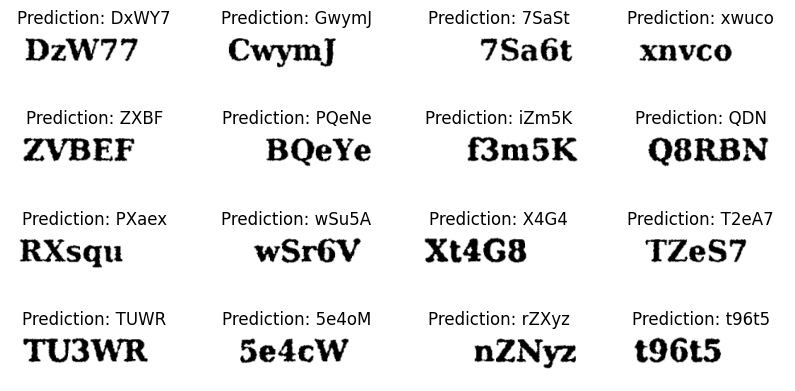

In [31]:
# Muestra visual (primer batch de validación, hasta 16 captchas)
for batch in validation_dataset.take(1):
    batch_images = batch["image"]
    batch_labels = batch["label"]

    preds = prediction_model.predict(batch_images)
    pred_textsv = decode_batch_predictions(preds)   

    orig_texts_v = [label_to_text(label) for label in batch_labels]

    _, ax = plt.subplots(4, 4, figsize=(10, 5))
    for i in range(len(pred_textsv)):
        img = (batch_images[i, :, :, 0] * 255).numpy().astype(np.uint8)
        title = f"Prediction: {pred_textsv[i]}"
        img = img.T
        ax[i // 4, i % 4].imshow(img, cmap="gray")
        ax[i // 4, i % 4].set_title(title)
        ax[i // 4, i % 4].axis("off")
plt.show()


In [ ]:
model.save(r'C:\Temas Auditoria\Usados\Prueba Runt\Modelo\OCR_captcha_model_V2_EX4.keras')

# El mejor de aqui es EX1
